
# Sensor2EventLog -- From Zero to Your First Process-Aware Event Log

**Welcome!** This notebook is a complete, self-contained tour of Sensor2EventLog, written for someone who has
never seen the framework before. We start from "what even is an event log?" and build up, one concept at a
time, all the way to exporting a real event log into PM4Py and evaluating how good it is.

You don't need any prior process-mining background. You do need basic Python and pandas.

**What we'll cover, in order:**

1. What is an event log, and why isn't raw sensor data one?
2. A tiny synthetic industrial process to use as our running example
3. The abstraction layer -- turning raw signals into features an expert can reason about
4. The Machine Teaching loop -- Plan, Explain, Review
5. The Hidden Markov Model -- turning features into a state sequence
6. From state sequence to interval event log
7. Exporting for process mining (XES, PM4Py)
8. Evaluating eventization quality
9. Where to go next

Grab a coffee -- we're doing this properly, from the ground up.



## Part 0 -- Before we start: what problem are we actually solving?

### What is an event log?

In process mining, an **event log** is a simple, structured record of what happened, when, in which case. At
minimum, every row has three things:

| case_id | activity | timestamp |
|---|---|---|
| batch_01 | Fill | 2026-01-01 08:00:00 |
| batch_01 | HeatUp | 2026-01-01 08:05:00 |
| batch_01 | Hold | 2026-01-01 08:10:00 |
| batch_01 | Cool | 2026-01-01 08:14:00 |
| batch_02 | Fill | 2026-01-01 09:00:00 |

- **case_id** groups events that belong to the same process instance (here, one batch of product).
- **activity** is a human-meaningful label for *what happened* ("Fill", "HeatUp", ...).
- **timestamp** tells you *when*.

Give a table like this to any process-mining tool (PM4Py, Celonis, Disco, ...) and it can discover the process
model, measure bottlenecks, check conformance against a reference model, and so on. Everything process mining does
starts from a table shaped like this.

### Why isn't raw sensor data already an event log?

Here's what you actually get from an industrial sensor stream:

| batch_id | timestamp | T (C) | Q_in | Q_out |
|---|---|---|---|---|
| batch_01 | 0 | 24.1 | 0.00 | 0.00 |
| batch_01 | 60 | 24.3 | 0.00 | 0.01 |
| batch_01 | 120 | 24.0 | 0.76 | 0.02 |
| batch_01 | 180 | 30.8 | 0.34 | 0.00 |
| batch_01 | 240 | 41.2 | 0.36 | 0.01 |

No `activity` column. No case boundaries beyond `batch_id`. Just continuous numeric measurements every 60
seconds, forever. A temperature of 41.2C doesn't *say* "I am in the HeatUp phase" -- a human has to know that,
and the knowledge usually lives in someone's head, not in the data.

This is the **eventization gap**: continuous, sub-symbolic sensor data on one side, discrete, symbolic process
activities on the other. Sensor2EventLog exists to bridge it.

### Two bad ways to close the gap (and why we avoid them)

- **Hand-written threshold rules** ("if T > 70, we're in Hold") are transparent but brittle -- they don't scale to
  more than a handful of states or sensors, and every process variant needs new rules written from scratch.
- **A pure black-box classifier** trained end-to-end can scale, but a plant engineer can't audit *why* it thinks
  timestamp 3000 is "Hold" rather than "HeatUp" -- which is a real problem in regulated domains like food and
  pharma manufacturing.

Sensor2EventLog's answer is **Machine Teaching**: keep a human expert firmly in the loop, but give them a
structured way to express and refine their knowledge -- as features and rules -- rather than either hand-coding
everything or handing control to an opaque model.



## Part 1 -- Setup

Sensor2EventLog is organized into five small, focused modules:

| Module | Role |
|---|---|
| `features/` | The **abstraction layer** -- turns raw signals into engineered features and rule-based event predicates. |
| `abstraction/` | The **Machine Teaching loop** -- orchestrates feature extraction, model training, and diagnostics. |
| `models/` | The **Hidden Markov Model** that decodes a state sequence from features. |
| `contextualization/` | The **EventLog** object -- turns a state sequence into an interval-based event log, with CSV/XES/PM4Py export. |
| `evaluation/` | The **rule diagnostics** -- scores how good your feature plan actually is. |
| `core/` | The **pipeline** that wires all of the above together end to end. |

We'll use these directly and individually first (so you can see what each one actually does), then use the full
`Sensor2EventLogPipeline` to run everything in one call.


In [1]:

# If you're running this notebook from the tutorial/ folder, make sure the repo root
# is on the Python path so the core, features, models, etc. packages import correctly.
import sys
from pathlib import Path

repo_root = Path.cwd()
if repo_root.name == "tutorial":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Repo root on path:", repo_root)


Repo root on path: /home/claude/Sensor2EventLog



## Part 2 -- Our running example: a synthetic pasteurization batch process

We'll use a small synthetic dataset modeled after a real pasteurization process (the same style of process
Sensor2EventLog was originally built for). Each batch moves through six states, always in the same order:

| State | What's physically happening | Typical sensor signature |
|---|---|---|
| Idle | Tank empty, nothing running | T flat at ambient, Q_in about 0, Q_out about 0 |
| Fill | Tank filling with product | Q_in high, T still near ambient |
| HeatUp | Product being heated | T rising steadily, Q_in moderate |
| Hold | Product held at pasteurization temperature | T flat and high, flows low |
| Cool | Product cooling down | T falling, Q_out starts rising |
| Discharge | Tank emptying | Q_out high, T settling near ambient |

We generate three synthetic batches with realistic sensor noise. In a real deployment this table would come from
your historian/SCADA system instead -- the rest of the notebook doesn't care where it came from, as long as it has
`batch_id`, `timestamp`, one column per sensor, and (for this tutorial) a `state` ground-truth label column we can
use to check our work.

> **Why is there a `state` column if the point is to *discover* the process from sensors?** Two reasons. First,
> it lets us evaluate how well the framework recovers the true states, which is exactly what you want while
> building trust in a new deployment. Second, the "supervised" HMM mode (Part 5) uses labeled batches to
> initialize the model -- you can label a handful of pilot batches by hand and let the framework generalize from
> there.


In [2]:

STATE_ORDER = ["Idle", "Fill", "HeatUp", "Hold", "Cool", "Discharge"]
STATE_DURATIONS = {"Idle": 3, "Fill": 5, "HeatUp": 5, "Hold": 4, "Cool": 4, "Discharge": 3}


def _state_profile(state, step, total_steps, batch_offset):
    """Simple, interpretable sensor patterns for one process state."""
    progress = step / max(total_steps - 1, 1)
    if state == "Idle":
        return {"T": 24 + batch_offset, "Q_in": 0.0, "Q_out": 0.0}
    if state == "Fill":
        return {"T": 24 + batch_offset, "Q_in": 0.75, "Q_out": 0.02}
    if state == "HeatUp":
        return {"T": 30 + 42 * progress + batch_offset, "Q_in": 0.35, "Q_out": 0.0}
    if state == "Hold":
        return {"T": 73 + batch_offset, "Q_in": 0.08, "Q_out": 0.03}
    if state == "Cool":
        return {"T": 73 - 33 * progress + batch_offset, "Q_in": 0.05, "Q_out": 0.18}
    if state == "Discharge":
        return {"T": 37 + batch_offset, "Q_in": 0.0, "Q_out": 0.72}
    raise ValueError(state)


def make_toy_dataset(n_batches=3, random_seed=7):
    rng = np.random.default_rng(random_seed)
    rows = []
    for batch_num in range(1, n_batches + 1):
        batch_id = f"batch_{batch_num:02d}"
        batch_offset = 0.4 * (batch_num - 1)
        timestamp = 0
        for state in STATE_ORDER:
            duration = STATE_DURATIONS[state]
            for step in range(duration):
                profile = _state_profile(state, step, duration, batch_offset)
                rows.append({
                    "batch_id": batch_id,
                    "timestamp": timestamp,
                    "state": state,
                    "T": round(profile["T"] + rng.normal(0, 0.45), 3),
                    "Q_in": max(0.0, round(profile["Q_in"] + rng.normal(0, 0.03), 3)),
                    "Q_out": max(0.0, round(profile["Q_out"] + rng.normal(0, 0.03), 3)),
                })
                timestamp += 60
    return pd.DataFrame(rows)


raw_df = make_toy_dataset(n_batches=3)
print(f"{len(raw_df)} rows, {raw_df['batch_id'].nunique()} batches")
raw_df.head(10)


72 rows, 3 batches


,batch_id,timestamp,state,T,Q_in,Q_out
0,batch_01,0,Idle,24.001,0.009,0.000
1,batch_01,60,Idle,23.599,0.000,0.000
2,batch_01,120,Idle,24.027,0.040,0.000
3,batch_01,180,Fill,23.721,0.765,0.031
4,batch_01,240,Fill,24.047,0.722,0.019
5,batch_01,300,Fill,24.313,0.710,0.006
6,batch_01,360,Fill,23.144,0.711,0.000
7,batch_01,420,Fill,23.894,0.712,0.028
8,batch_01,480,HeatUp,30.071,0.344,0.000
9,batch_01,540,HeatUp,40.258,0.349,0.003



Let's plot one batch's raw sensor traces. Notice that nothing in the data itself announces "this is where HeatUp
ends and Hold begins" -- the state boundaries are a human interpretation of the underlying physics, and that
interpretation is exactly what we're trying to teach the framework.


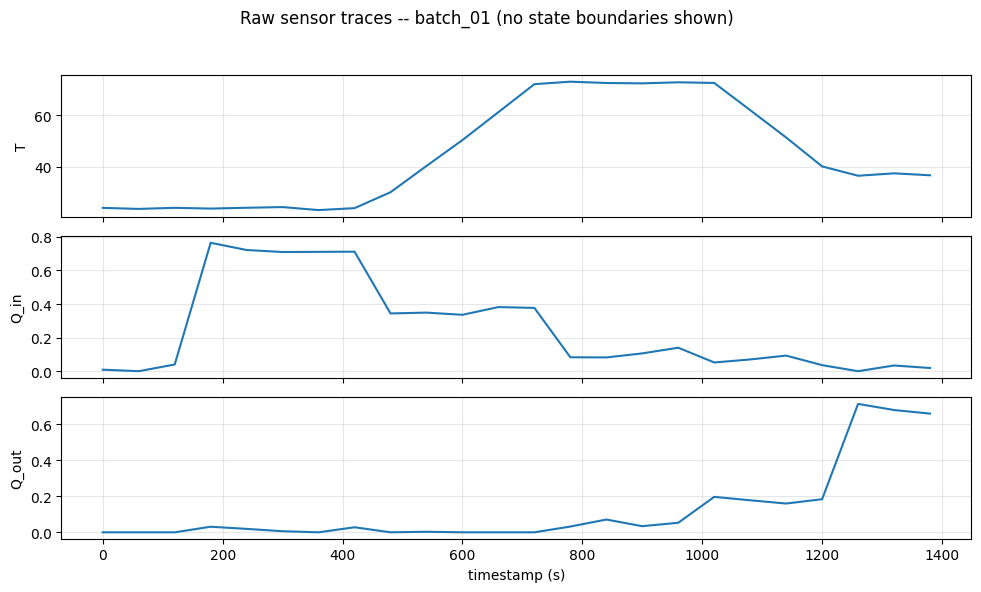

In [3]:

def plot_raw_batch(df, batch_id, cols=("T", "Q_in", "Q_out")):
    batch_df = df[df["batch_id"] == batch_id].sort_values("timestamp")
    fig, axes = plt.subplots(len(cols), 1, figsize=(10, 6), sharex=True)
    for ax, col in zip(axes, cols):
        ax.plot(batch_df["timestamp"], batch_df[col], linewidth=1.5)
        ax.set_ylabel(col)
        ax.grid(alpha=0.3)
    axes[-1].set_xlabel("timestamp (s)")
    fig.suptitle(f"Raw sensor traces -- {batch_id} (no state boundaries shown)")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_raw_batch(raw_df, "batch_01")



## Part 3 -- The abstraction layer: engineering features an expert can reason about

The `ModularFeatureLibrary` in `features/feature_library.py` computes six families of features. Each family
answers a different kind of question about the raw signal:

| Family | Question it answers | What it computes |
|---|---|---|
| **statistical** | "What's the recent typical level of this signal?" | Rolling mean over a window |
| **temporal** | "Is this signal rising, falling, or flat, and how fast?" | Differences, sign of change, smoothed rate |
| **stability** | "Has this signal settled down?" | A stability score, a binary "stable" flag, and a running count of consecutive stable steps |
| **interaction** | "How do two signals relate to each other?" | Products and ratios between signal pairs |
| **event** | "Does this timestamp match an expert-defined rule?" | Binary flags from a small rule-expression DSL (see below) |
| **contextual** | "Where are we within the batch?" | e.g. relative position within the current case |

### The event-predicate DSL

The `event` family is where domain knowledge enters directly as **rules over other features**, written as
readable boolean expressions:

```python
{"hold_rule": "(T > 70) & (T_stable_flag == 1)"}
```

This says: *"flag this timestamp as a Hold-candidate if temperature is above 70C **and** the temperature has
been stable"* -- combining a raw-signal condition (`T > 70`) with a *derived* feature (`T_stable_flag`).

> **What a rule can actually reference, precisely:** any raw column from your data, plus a fixed, automatically
> computed set of per-signal helpers for every numeric column: `{signal}_diff`, `{signal}_diff_smooth`,
> `{signal}_abs_diff`, `{signal}_stability`, and `{signal}_stable_flag`. This set is computed independently for
> rule evaluation -- it is **not** the same as the `temporal`/`stability` family columns elsewhere in your feature
> table (for instance there is no `{signal}_diff_sign` available inside a rule, even though the `temporal` family
> computes one). If a rule references a name outside this fixed set, it silently evaluates to all-`False` and
> prints an "Error evaluating rule" message -- worth watching for the first few times you write rules.

Let's define a feature plan and compute the features directly, so you can see the intermediate table before any
modeling happens.


In [4]:

from features.feature_library import ModularFeatureLibrary

feature_plan = {
    "statistical": ["T", "Q_in", "Q_out"],
    "temporal": ["T", "Q_in", "Q_out"],
    "stability": ["T"],
    "interaction": [["T", "Q_in"], ["T", "Q_out"]],
    "event": [
        {"fill_rule": "(Q_in > 0.5) & (Q_out < 0.1)"},
        {"hold_rule": "(T > 70) & (T_stable_flag == 1)"},
        {"discharge_rule": "(Q_out > 0.5) & (Q_in < 0.1)"},
    ],
    "contextual": ["batch_position"],
}

feature_library = ModularFeatureLibrary(window_sizes=[5], stability_eps=1, peak_threshold=0.1)
features = feature_library.compute_features(raw_df, feature_plan)

print(f"{features.shape[1]} engineered feature columns from 3 raw signals")
features.filter(like="T_").head()


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule
28 engineered feature columns from 3 raw signals


,T_roll_mean_5,T_diff,T_diff_sign,T_diff_smooth,T_abs_diff,T_stability,T_stable_flag,T_consecutive_stable,T_x_Q_in,T_ratio_Q_in,T_x_Q_out,T_ratio_Q_out
0,24.001000,0.000,0.0,0.000000,0.000,1.000000,1,1,0.216009,3.209955,0.000000,0.000000
1,23.800000,-0.402,-1.0,-0.241200,0.402,0.713267,1,2,0.000000,0.000000,0.000000,0.000000
2,23.875667,0.428,1.0,0.075789,0.428,0.700280,1,3,0.961080,3.180734,0.000000,0.000000
3,23.837000,-0.306,-1.0,-0.082800,0.306,0.765697,1,4,18.146565,2.639502,0.735351,3.177123
4,23.879000,0.326,1.0,0.074133,0.326,0.754148,1,5,17.361934,2.677267,0.456893,3.201931



Notice `T_stable_flag` -- this is exactly the derived feature our `hold_rule` referenced above. Let's look at the
`event_*` columns, which are the actual rule outputs:


In [5]:

event_cols = [c for c in features.columns if c.startswith("event_")]
print("Event/rule columns:", event_cols)
features[event_cols].sum().rename("times triggered")


Event/rule columns: ['event_fill_rule', 'event_hold_rule', 'event_discharge_rule']


event_fill_rule         15
event_hold_rule         13
event_discharge_rule     9
Name: times triggered, dtype: int64


## Part 4 -- The Machine Teaching loop: Plan, Explain, Review

Writing rules is easy. Knowing whether they're *good* rules is the hard part, and this is what the "Explain" and
"Review" steps of Machine Teaching are for. The `RuleDiagnosticAnalyzer` scores every rule against the true
`state` labels using two numbers:

- **Coverage** -- of all the timestamps truly in state *S*, what fraction did this rule catch?
  (Recall, from the state's point of view.)
- **Precision** -- of all the timestamps this rule fired on, what fraction were truly in state *S*?
  (How much do you trust it when it says yes?)

A rule with high coverage but low precision is **overly sensitive** -- it fires too eagerly and needs a tighter
condition (often a stability or interaction feature). A rule with high precision but low coverage is **overly
specific** -- it's too cautious and misses cases; relax it. Sensor2EventLog computes both automatically and turns
the pattern into a concrete, prioritized recommendation.

Let's run the diagnostic analyzer on our current feature plan.


In [6]:

from evaluation.rule_analyzer import RuleDiagnosticAnalyzer

analyzer = RuleDiagnosticAnalyzer(coverage_threshold=0.6, precision_threshold=0.7, explainability_threshold=0.3)
diagnostics = analyzer.compute_rule_metrics(raw_df, features[event_cols])
analyzer.print_diagnostic_report(diagnostics)


RULE DIAGNOSTIC REPORT

1. RULE PERFORMANCE SUMMARY:
----------------------------------------

Rule: event_fill_rule
  State: Idle            | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Fill            | Coverage: 100.0% | Precision: 100.0% | Effectiveness: 100.0%
  State: HeatUp          | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Hold            | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Cool            | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Discharge       | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%

Rule: event_hold_rule
  State: Idle            | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Fill            | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: HeatUp          | Coverage:   0.0% | Precision:   0.0% | Effectiveness:   0.0%
  State: Hold            | Coverage:  83.3% | Precision:  76.9% | Ef


### Seeing the loop actually close: fixing a deliberately weak rule

Our current plan has no rule at all for `HeatUp`, `Idle`, or `Cool` -- the report above should flag those as
**unexplainable states** with a concrete recommendation. Let's "Review" the plan by adding rules for them, and
see the diagnostics improve. This before/after is the whole Machine Teaching loop in miniature: Plan (write a
rule), Explain (see the diagnostics), Review (fix the rule), repeat.


In [7]:

feature_plan_v2 = dict(feature_plan)
feature_plan_v2["event"] = feature_plan["event"] + [
    {"idle_rule": "(Q_in < 0.05) & (Q_out < 0.05) & (T_stable_flag == 1)"},
    {"heatup_rule": "(T_diff > 0.1) & (Q_in > 0.1) & (T_stable_flag == 0)"},
    {"cool_rule": "(T_diff < -0.1) & (Q_out > 0.05)"},
]

features_v2 = feature_library.compute_features(raw_df, feature_plan_v2)
event_cols_v2 = [c for c in features_v2.columns if c.startswith("event_")]
diagnostics_v2 = analyzer.compute_rule_metrics(raw_df, features_v2[event_cols_v2])

print(f"Unexplainable states before: {diagnostics['unexplainable_states']}")
print(f"Unexplainable states after:  {diagnostics_v2['unexplainable_states']}")
print(f"Recommendations before: {len(diagnostics['recommendations'])}")
print(f"Recommendations after:  {len(diagnostics_v2['recommendations'])}")


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule
Created named event feature: event_idle_rule
Created named event feature: event_heatup_rule
Created named event feature: event_cool_rule
Unexplainable states before: ['Idle', 'HeatUp', 'Cool']
Unexplainable states after:  []
Recommendations before: 18
Recommendations after:  31



Fewer unexplainable states and fewer high-priority recommendations -- the loop worked. In a real project you'd
keep iterating like this, informed by domain knowledge, until the diagnostics look healthy across every state.



## Part 5 -- From features to states: the Hidden Markov Model

Rules alone rarely cover every timestamp cleanly -- sensor noise means a perfectly good rule still misses a few
edge-case moments, and real processes have states that are genuinely hard to write a crisp rule for. This is
where the **Hidden Markov Model (HMM)** comes in: it treats the true process state at each timestamp as a
*hidden* variable, and learns (a) how states tend to follow each other (the transition matrix) and (b) what
feature values typically look like in each state (the emission distributions), then decodes the most likely full
state sequence with the Viterbi algorithm.

Sensor2EventLog supports two training modes:

- **Supervised** -- uses your labeled batches to directly estimate the start probabilities, transition matrix, and
  per-state feature distributions, then refines them with a few EM iterations. Use this when you have at least a
  handful of labeled pilot batches, which is exactly our situation here.
- **Unsupervised** -- fits a vanilla Gaussian HMM with no labels at all, then aligns the discovered hidden states
  to your named states after the fact (using the Hungarian algorithm) purely for evaluation purposes. Use this
  when you have *no* labeled data yet -- the framework will still discover a plausible number of recurring
  regimes, you just have to name them yourself afterward.

We'll run the full `Sensor2EventLogPipeline` (which wires feature extraction, HMM, and event log generation
together) in both modes and compare.

> **A framework bug worth knowing about:** as shipped, `config.HMM_CONFIG["covariance_type"]` defaults to
> `"diag"`, but `train_supervised()` always builds *full* covariance matrices when initializing from labels
> (`utils.hmm_utils.emissions_from_labels`), regardless of that setting. That mismatch makes supervised mode
> crash out of the box with a `hmmlearn` shape error. Until that's fixed upstream, we work around it below by
> explicitly requesting `"full"` covariance for this run -- fine for our small feature set, but worth flagging if
> you hit the same error on your own data.


In [8]:

import types
import config as base_config
from core.pipeline import Sensor2EventLogPipeline

# Save our (small) dataset to disk, since the pipeline reads from a CSV path.
dataset_path = Path("tutorial_zero_to_hero_data.csv")
raw_df.to_csv(dataset_path, index=False)

# Use a throwaway config so we don't overwrite the project's real output paths.
cfg = types.SimpleNamespace(**{k: v for k, v in base_config.__dict__.items() if k.isupper()})
cfg.PATHS = {"event_log": "tutorial_event_log.csv", "filtered_log": "tutorial_event_log_filtered.csv"}
# Workaround for the covariance-type mismatch in supervised mode (see note above).
cfg.HMM_CONFIG = {**base_config.HMM_CONFIG, "covariance_type": "full"}

pipeline = Sensor2EventLogPipeline(cfg)

result_supervised = pipeline.run(
    data_path=str(dataset_path),
    feature_plan=feature_plan_v2,
    mode="supervised",
    random_seed=42,
    return_intermediate=True,
    min_duration_seconds=0.0,
)

print("Supervised mode -- predicted state sequence for the first 15 timestamps:")
print(result_supervised["predictions"][:15])


Fitting a model with 3197 free scalar parameters with only 744 data points will result in a degenerate solution.


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule
Created named event feature: event_idle_rule
Created named event feature: event_heatup_rule
Created named event feature: event_cool_rule

Training supervised HMM...

== Supervised HMM (Test) ==
              precision    recall  f1-score   support

        Idle       1.00      1.00      1.00         6
        Fill       1.00      1.00      1.00        10
      HeatUp       1.00      1.00      1.00        10
        Hold       1.00      1.00      1.00         8
        Cool       1.00      1.00      1.00         8
   Discharge       1.00      1.00      1.00         6

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48

Confusion matrix (rows=true, cols=pred):
           Idle  Fill  HeatUp  Hold  Cool  Discharge
Idle          6     0       0

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [9]:

# Same data, same feature plan, but discover states without ever showing the model the labels.
pipeline_unsup = Sensor2EventLogPipeline(cfg)
result_unsupervised = pipeline_unsup.run(
    data_path=str(dataset_path),
    feature_plan=feature_plan_v2,
    mode="unsupervised",
    n_unsup=len(STATE_ORDER),
    random_seed=42,
    return_intermediate=True,
    min_duration_seconds=0.0,
)


Fitting a model with 3197 free scalar parameters with only 744 data points will result in a degenerate solution.


Created named event feature: event_fill_rule
Created named event feature: event_hold_rule
Created named event feature: event_discharge_rule
Created named event feature: event_idle_rule
Created named event feature: event_heatup_rule
Created named event feature: event_cool_rule

Training unsupervised HMM...

== Unsupervised HMM (mapped) — Test ==
              precision    recall  f1-score   support

        Idle       1.00      1.00      1.00         6
        Fill       0.43      0.60      0.50        10
      HeatUp       0.60      0.60      0.60        10
        Hold       0.80      1.00      0.89         8
        Cool       0.67      0.50      0.57         8
   Discharge       1.00      0.33      0.50         6

    accuracy                           0.67        48
   macro avg       0.75      0.67      0.68        48
weighted avg       0.71      0.67      0.66        48

Confusion matrix (rows=true, cols=pred):
           Idle  Fill  HeatUp  Hold  Cool  Discharge
Idle          6 

Event log saved to: tutorial_event_log.csv
Event log saved to: tutorial_event_log_filtered.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



One subtlety before we compare accuracy: unsupervised mode has no idea our states are called "Idle", "Fill",
and so on -- it only outputs arbitrary cluster IDs (0, 1, 2, ...). Those IDs aren't in the same order as our
`STATE_ORDER` list, so comparing them to the true labels directly would be meaningless (cluster "2" might
correspond to "Hold" one run and "Cool" the next). We have to find the best matching between cluster IDs and true
states first -- exactly the Hungarian-algorithm alignment step the framework itself uses internally, which is why
supervised mode gets a direct 1:1 comparison above but unsupervised mode needs this extra step.


In [10]:

from scipy.optimize import linear_sum_assignment

def aligned_accuracy(pred_clusters, true_idx, n_states):
    """Best-case accuracy after optimally matching cluster IDs to true state indices."""
    pred_clusters = np.asarray(pred_clusters)
    contingency = np.zeros((n_states, n_states), dtype=int)
    for t, p in zip(true_idx, pred_clusters):
        if p < n_states:
            contingency[t, p] += 1
    true_rows, pred_cols = linear_sum_assignment(-contingency)
    mapping = {pred: true for true, pred in zip(true_rows, pred_cols)}
    mapped_preds = np.array([mapping.get(p, -1) for p in pred_clusters])
    return (mapped_preds == true_idx).mean()

true_labels = raw_df.sort_values(["batch_id", "timestamp"])["state"].map(
    {s: i for i, s in enumerate(STATE_ORDER)}
).to_numpy()

supervised_acc = (np.asarray(result_supervised["predictions"]) == true_labels).mean()
unsupervised_acc = aligned_accuracy(result_unsupervised["predictions"], true_labels, len(STATE_ORDER))

print(f"Supervised agreement with ground truth:                {supervised_acc:.1%}")
print(f"Unsupervised agreement with ground truth (post-alignment): {unsupervised_acc:.1%}")


Supervised agreement with ground truth:                100.0%
Unsupervised agreement with ground truth (post-alignment): 66.7%



Even on this small, clean synthetic example, supervised mode reaches perfect agreement while unsupervised mode
-- after the best possible cluster alignment -- lands well short of it. That gap is the practical argument for
labeling even a handful of pilot batches when you can: **supervised mode is usually both more accurate and far
more stable across runs**, because it starts from a sensible, knowledge-informed initialization instead of a
random one. Unsupervised mode remains a genuinely useful fallback when no labels exist at all, but treat its
state *count* and *naming* as a starting hypothesis to validate, not a final answer.



## Part 6 -- From a state sequence to an interval event log

A raw predicted state *sequence* -- one label per timestamp -- still isn't an event log. The last step collapses
consecutive identical predictions into intervals (`case_id`, `activity`, `start_timestamp`, `end_timestamp`,
`duration_seconds`), and then removes segments shorter than `min_duration_seconds`, since a state that only
"lasted" for one noisy timestamp before flickering back is almost always noise, not a genuine transition.

`Sensor2EventLogPipeline.run()` already did this for us -- it's sitting in `result_supervised["event_log"]` as an
`EventLog` object.


In [11]:

event_log = result_supervised["event_log"]
print(event_log)
event_log.to_dataframe().head(12)


EventLog(cases=3, events=18, activities=6)


,case_id,activity_sequence,activity,start_timestamp,end_timestamp,duration_seconds,event_count
0,batch_01,1,Idle,2023-01-01 00:00:00,2023-01-01 00:02:00,120.0,3
1,batch_01,2,Fill,2023-01-01 00:03:00,2023-01-01 00:07:00,240.0,5
2,batch_01,3,HeatUp,2023-01-01 00:08:00,2023-01-01 00:12:00,240.0,5
3,batch_01,4,Hold,2023-01-01 00:13:00,2023-01-01 00:16:00,180.0,4
4,batch_01,5,Cool,2023-01-01 00:17:00,2023-01-01 00:20:00,180.0,4
5,batch_01,6,Discharge,2023-01-01 00:21:00,2023-01-01 00:23:00,120.0,3
6,batch_02,1,Idle,2023-01-01 00:00:00,2023-01-01 00:02:00,120.0,3
7,batch_02,2,Fill,2023-01-01 00:03:00,2023-01-01 00:07:00,240.0,5
8,batch_02,3,HeatUp,2023-01-01 00:08:00,2023-01-01 00:12:00,240.0,5
9,batch_02,4,Hold,2023-01-01 00:13:00,2023-01-01 00:16:00,180.0,4


In [12]:

event_log.get_statistics()


{'total_cases': 3,
 'total_events': 18,
 'unique_activities': 6,
 'avg_case_duration': np.float64(1080.0),
 'activity_frequencies': {'Idle': 3,
  'Fill': 3,
  'HeatUp': 3,
  'Hold': 3,
  'Cool': 3,
  'Discharge': 3}}


Compare that against the *unfiltered* segments (`min_duration_seconds=0.0` here, since our toy batches are short) --
in a real deployment with second-level sampling, raising `min_duration_seconds` to a few seconds is usually enough
to remove spurious one-timestamp flickers without losing genuine short states.



## Part 7 -- Exporting for process mining: XES and PM4Py

The whole point of eventization is to hand the result to real process-mining tooling. `EventLog` exports directly
to CSV (already used above), to the industry-standard **XES** format, and to a native **PM4Py** event log object
you can keep working with in the same notebook.

> **A licensing note, since we're about to use it:** PM4Py's open-source distribution is licensed under **AGPLv3**.
> That's a copyleft license -- if you build and distribute a product that uses it, that product generally needs to
> be open-sourced too, unless you buy PM4Py's commercial license. This has no bearing on Sensor2EventLog itself
> (which only calls PM4Py optionally, as an external tool, and is under its own MIT license) -- it only matters if
> *your* downstream application embeds PM4Py.

> **Another framework bug worth knowing about:** `EventLog.to_xes()` and `EventLog.to_pm4py()` both call
> `pm4py.format_dataframe_to_event_log(...)`, a function that no longer exists in current PM4Py releases (the API
> has moved to `pm4py.format_dataframe()` + `pm4py.convert_to_event_log()`). Calling either method as-shipped
> raises `AttributeError: module 'pm4py' has no attribute 'format_dataframe_to_event_log'` against a current
> PM4Py install. Below we work around it by preparing the dataframe with today's API directly -- worth patching
> `contextualization/event_log.py` at the source, since this otherwise silently breaks both export paths.


In [13]:

import pm4py

# Work around the to_pm4py()/to_xes() API-drift bug noted above: build the PM4Py-formatted
# dataframe ourselves with the current PM4Py API instead of calling the broken methods.
pm4py_df = event_log.to_dataframe().rename(columns={
    "case_id": "case:concept:name",
    "activity": "concept:name",
    "start_timestamp": "time:timestamp",
})
pm4py_df = pm4py.format_dataframe(
    pm4py_df, case_id="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp"
)
print(f"{pm4py_df['case:concept:name'].nunique()} cases, {len(pm4py_df)} events, ready for PM4Py")




  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




3 cases, 18 events, ready for PM4Py



Now let's actually *do* some process mining: discover a Directly-Follows Graph (the simplest process model --
which activity tends to follow which) straight from our eventized log.


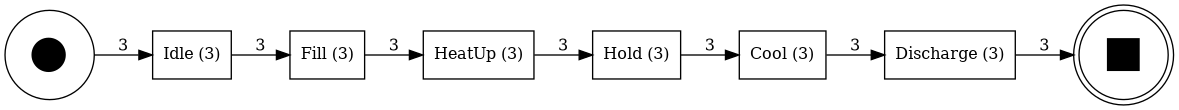

In [14]:

dfg, start_activities, end_activities = pm4py.discover_dfg(
    pm4py_df, case_id_key="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp"
)
pm4py.view_dfg(dfg, start_activities, end_activities, format="png")



That picture was **discovered directly from sensor data** -- nobody hand-drew it. Let's go one step further and
discover an actual process model (a Petri net) using the inductive miner, then check how well our own event log
conforms to it (a sanity check: it should conform almost perfectly, since we generated the log from the model
we're now discovering).


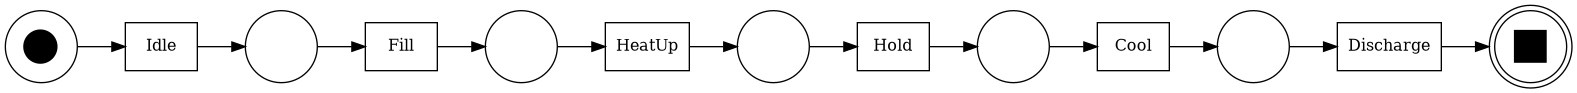

In [15]:

net, im, fm = pm4py.discover_petri_net_inductive(
    pm4py_df, case_id_key="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp"
)
pm4py.view_petri_net(net, im, fm, format="png")


In [16]:

fitness = pm4py.fitness_token_based_replay(
    pm4py_df, net, im, fm,
    case_id_key="case:concept:name", activity_key="concept:name", timestamp_key="time:timestamp",
)
fitness


{'perc_fit_traces': 100.0,
 'average_trace_fitness': 1.0,
 'log_fitness': 1.0,
 'percentage_of_fitting_traces': 100.0}


A `log_fitness` close to `1.0` means our discovered event log replays cleanly against the discovered model --
a good sign that the eventization pipeline produced something internally consistent, not just plausible-looking
noise.



## Part 8 -- Evaluating eventization quality end to end

We already used `RuleDiagnosticAnalyzer` in Part 4 to score individual **rules**, before any HMM was involved.
Now that we have a full decoded **event log**, we can additionally ask a more end-to-end question: how well does
the final segmented log line up with the ground truth, timestamp for timestamp?

This is a simple, transparent version of the "eventization quality" evaluation -- comparing predicted labels
against true labels one timestamp at a time (state-label accuracy), which is one of four evaluation angles worth
tracking (the others -- event-detection precision/recall, trace-level similarity, and process-model quality --
get their own dedicated tutorial; see Part 9).


In [17]:

from sklearn.metrics import classification_report

state_names = {i: s for i, s in enumerate(STATE_ORDER)}
y_true_named = [state_names[i] for i in true_labels]
y_pred_named = [state_names[i] for i in result_supervised["predictions"]]

print(classification_report(y_true_named, y_pred_named, zero_division=0))


              precision    recall  f1-score   support

        Cool       1.00      1.00      1.00        12
   Discharge       1.00      1.00      1.00         9
        Fill       1.00      1.00      1.00        15
      HeatUp       1.00      1.00      1.00        15
        Hold       1.00      1.00      1.00        12
        Idle       1.00      1.00      1.00         9

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72




## Part 9 -- Recap, and where to go next

Here's the full journey we just walked, end to end:

1. **The gap** -- raw sensor streams aren't event logs; process mining needs `(case, activity, timestamp)`.
2. **Features** (`features/`) -- six families turn raw signals into an expert-legible vocabulary, including a
   rule-predicate DSL for direct domain-knowledge injection.
3. **Diagnostics** (`evaluation/`) -- coverage/precision/explainability scores turn "is this rule good?" into a
   measurable, iterable question -- the heart of the Machine Teaching loop.
4. **The HMM** (`models/`) -- decodes a full state sequence from features, in supervised or unsupervised mode.
5. **The EventLog** (`contextualization/`) -- collapses the state sequence into clean intervals, with built-in
   CSV/XES/PM4Py export.
6. **Process mining** -- the exported log plugs directly into PM4Py's discovery and conformance-checking tools.
7. **Evaluation** -- from per-rule metrics all the way to end-to-end state-label accuracy.

### Where to go deeper

This notebook deliberately moved fast through every stage to show you the whole shape of the framework. Each
stage has more nuance than fit here, and gets its own focused tutorial:

- **The Machine Teaching loop in depth**, iterating on a genuinely weak feature plan across several rounds.
- **Supervised vs. unsupervised HMM**, compared systematically on harder, noisier data.
- **The event-predicate DSL**, in depth -- more operators, referencing multiple derived features at once.
- **The real bundled pasteurization dataset** (`main.py`), including a frank discussion of where the abstraction
  currently falls short.
- **Eventization quality**, covering all four evaluation angles (detection precision/recall, state-label
  accuracy, trace-level similarity, process-model quality) rather than just state-label accuracy.
- **Full PM4Py integration**, covering conformance and performance analysis beyond the DFG/Petri-net taste we got
  here.

See the tutorials table in the project [README](../README.md) for links as these come online.
